In [ ]:
INDUSTRIAL CARBON EMISSION PREDICTION

In [60]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [15]:
# 2. LOAD DATASET

df = pd.read_csv("Steel_industry.csv")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


First 5 rows:
          Date_Time  Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0  01-01-2018 00:15       3.17                                  2.95   
1  01-01-2018 00:30       4.00                                  4.46   
2  01-01-2018 00:45       3.24                                  3.28   
3  01-01-2018 01:00       3.31                                  3.56   
4  01-01-2018 01:15       3.82                                  4.50   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   
3                                   0.0        0.0   
4                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         73.21                         100.0   900   
1                         66.77                         100.0  1800   
2             

In [16]:
# 3. REMOVE DUPLICATES

print("\nNumber of duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


Number of duplicate rows: 0
Shape after removing duplicates: (35041, 11)


In [20]:
# 4. CONVERT DATE_TIME

df["Date_Time"] = pd.to_datetime(df["Date_Time"],errors="coerce")

print("\nDate range:")
print(df["Date_Time"].min())
print(df["Date_Time"].max())


Date range:
2018-01-01 00:00:00
2018-12-12 23:45:00


In [18]:
# 5. CREATE TIME FEATURES

df["Hour"] = df["Date_Time"].dt.hour
df["Day"] = df["Date_Time"].dt.day
df["Month"] = df["Date_Time"].dt.month
df["Day_Number"] = df["Date_Time"].dt.dayofweek

print("\nTime features created successfully.")


Time features created successfully.


In [21]:
# 6. STATISTICS

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

print(df.describe())



STATISTICAL SUMMARY
                           Date_Time     Usage_kWh  \
count                          13824  35041.000000   
mean   2018-06-22 11:52:29.999999744     27.386229   
min              2018-01-01 00:00:00      0.000000   
25%              2018-03-27 05:56:15      3.200000   
50%              2018-06-21 23:52:30      4.570000   
75%              2018-09-17 11:48:45     51.230000   
max              2018-12-12 23:45:00    157.180000   
std                              NaN     33.444133   

       Lagging_Current_Reactive.Power_kVarh  \
count                          35041.000000   
mean                              13.035012   
min                                0.000000   
25%                                2.300000   
50%                                5.000000   
75%                               22.640000   
max                               96.910000   
std                               16.305916   

       Leading_Current_Reactive_Power_kVarh     CO2(tCO2)  \
count  

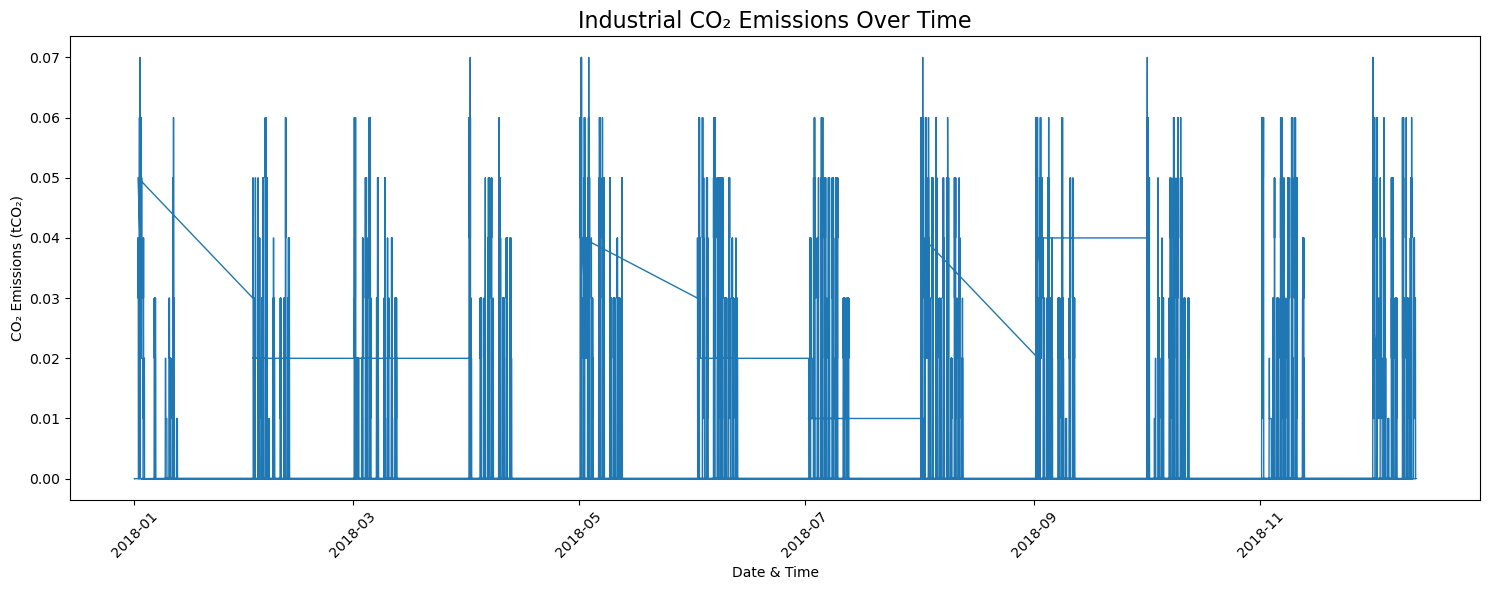

In [23]:
# 7. GRAPH 1 - CO2 EMISSIONS OVER TIME

plt.figure(figsize=(15, 6))

plt.plot(df["Date_Time"],df["CO2(tCO2)"],linewidth=1)

plt.title("Industrial CO₂ Emissions Over Time",fontsize=16)

plt.xlabel("Date & Time")
plt.ylabel("CO₂ Emissions (tCO₂)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

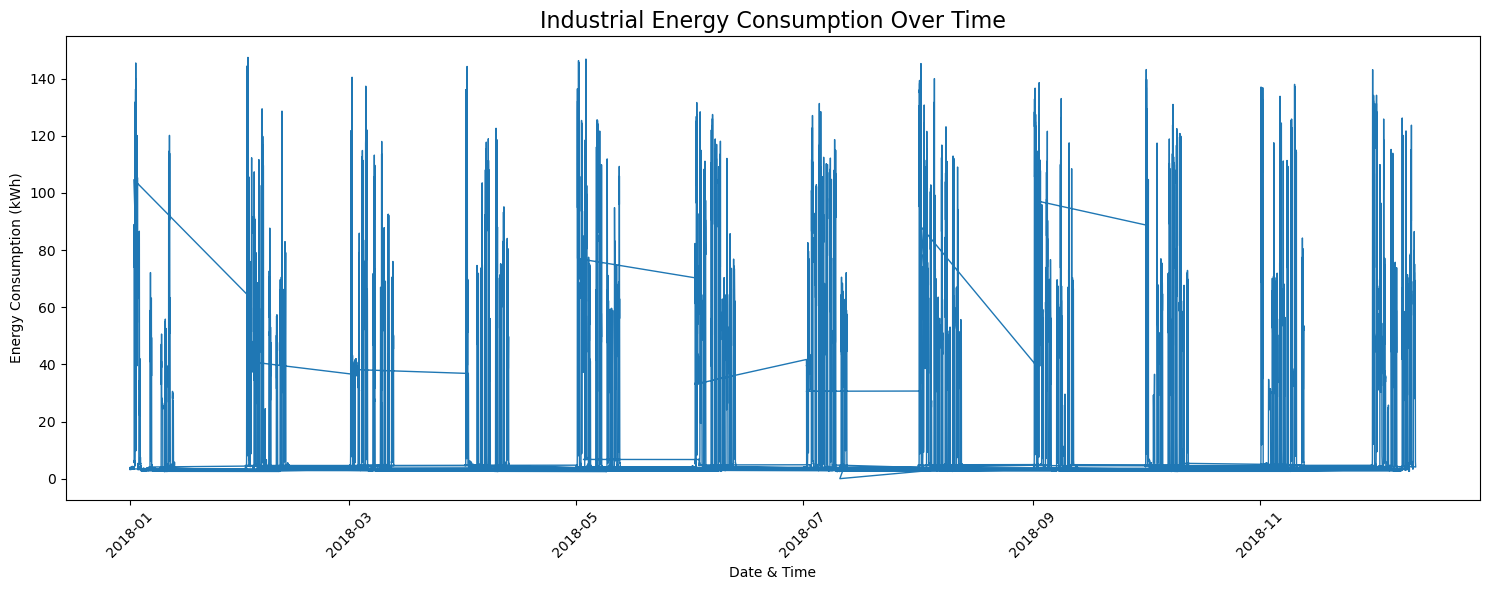

In [24]:
# 8. GRAPH 2 - ENERGY CONSUMPTION OVER TIME

plt.figure(figsize=(15, 6))

plt.plot(
    df["Date_Time"],
    df["Usage_kWh"],
    linewidth=1
)

plt.title(
    "Industrial Energy Consumption Over Time",
    fontsize=16
)

plt.xlabel("Date & Time")
plt.ylabel("Energy Consumption (kWh)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

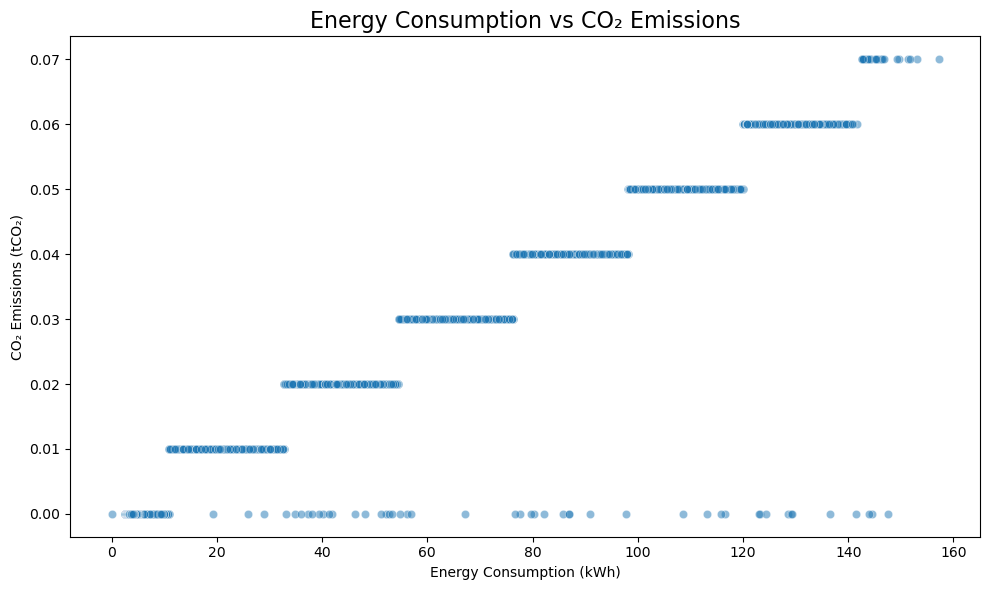

In [25]:
# 9. GRAPH 3 - ENERGY VS CO2

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Usage_kWh",
    y="CO2(tCO2)",
    alpha=0.5
)

plt.title(
    "Energy Consumption vs CO₂ Emissions",
    fontsize=16
)

plt.xlabel("Energy Consumption (kWh)")
plt.ylabel("CO₂ Emissions (tCO₂)")

plt.tight_layout()
plt.show()

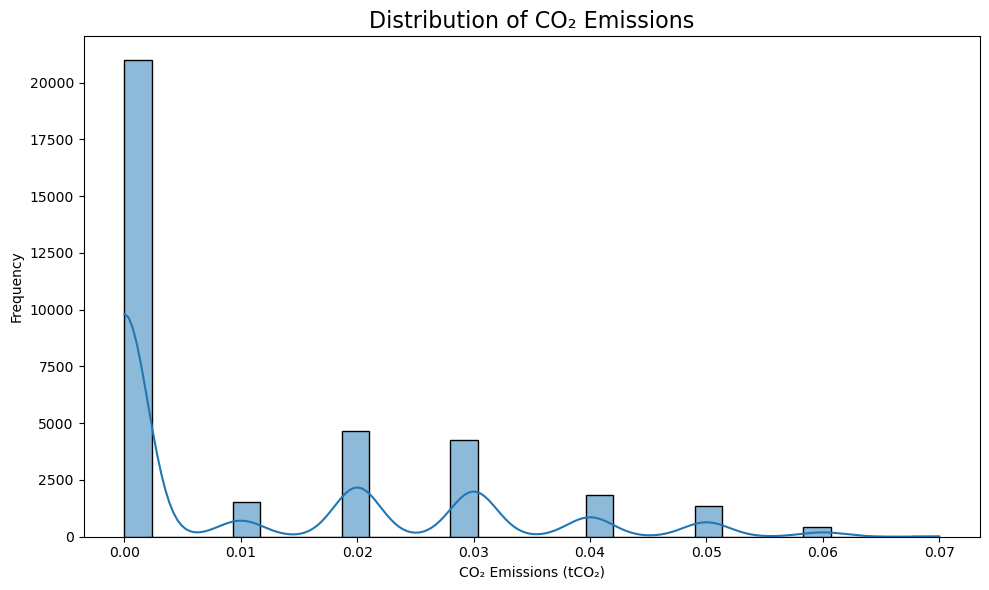

In [30]:
# 10. GRAPH 4 - CO2 DISTRIBUTION

plt.figure(figsize=(10, 6))

sns.histplot(df["CO2(tCO2)"],bins=30,kde=True)

plt.title("Distribution of CO₂ Emissions",fontsize=16)

plt.xlabel("CO₂ Emissions (tCO₂)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

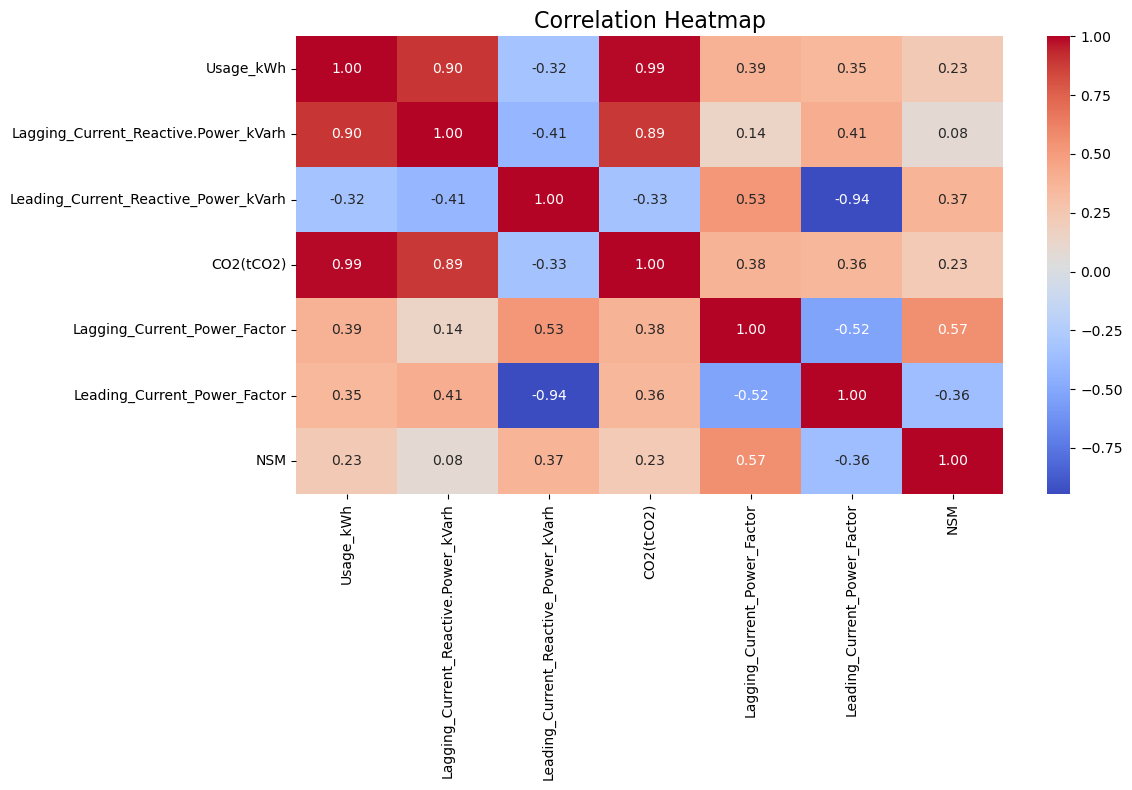

In [31]:
# 11. GRAPH 5 - CORRELATION HEATMAP

numeric_columns = ["Usage_kWh","Lagging_Current_Reactive.Power_kVarh","Leading_Current_Reactive_Power_kVarh",
    "CO2(tCO2)","Lagging_Current_Power_Factor","Leading_Current_Power_Factor",
    "NSM"]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(correlation,annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation Heatmap",fontsize=16)

plt.tight_layout()
plt.show()

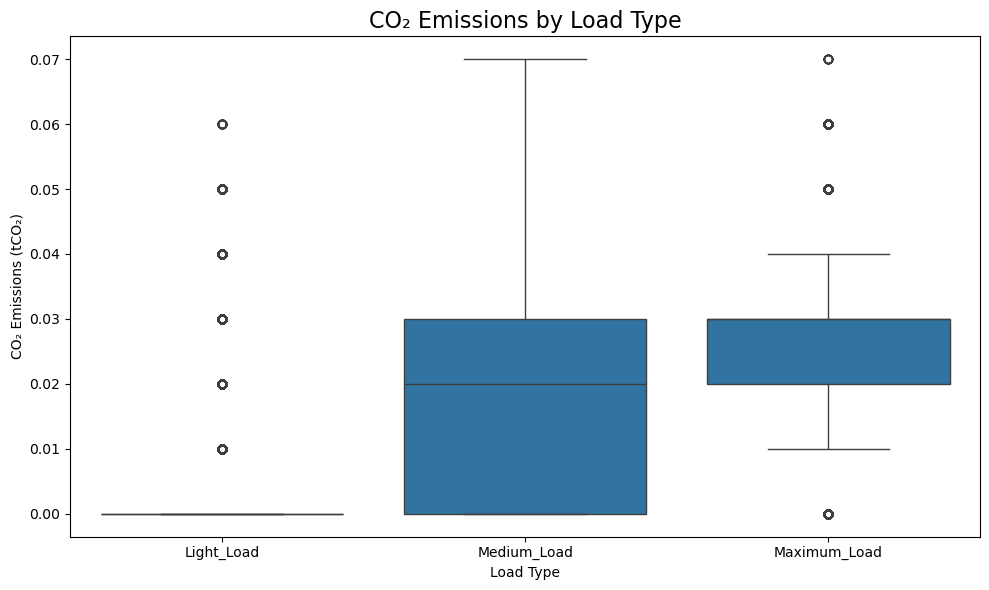

In [34]:
# 12. GRAPH 6 - CO2 BY LOAD TYPE

plt.figure(figsize=(10, 6))

sns.boxplot(data=df,x="Load_Type",y="CO2(tCO2)")

plt.title("CO₂ Emissions by Load Type",fontsize=16)

plt.xlabel("Load Type")
plt.ylabel("CO₂ Emissions (tCO₂)")

plt.tight_layout()
plt.show()

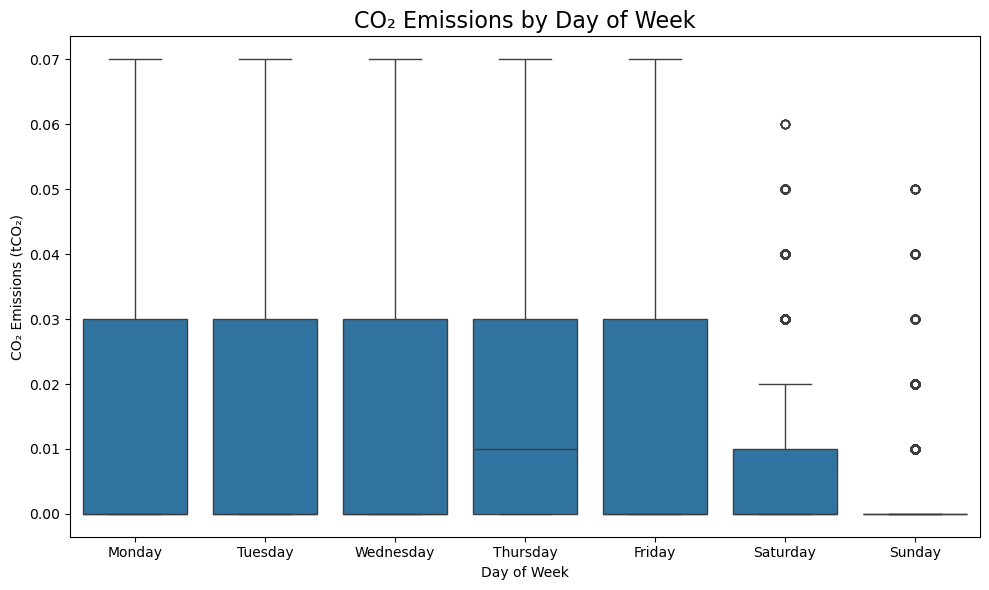

In [35]:
# 13. GRAPH 7 - CO2 BY DAY OF WEEK

plt.figure(figsize=(10, 6))

sns.boxplot(data=df,x="Day_Of_Week",y="CO2(tCO2)")

plt.title("CO₂ Emissions by Day of Week",fontsize=16)

plt.xlabel("Day of Week")
plt.ylabel("CO₂ Emissions (tCO₂)")

plt.tight_layout()
plt.show()

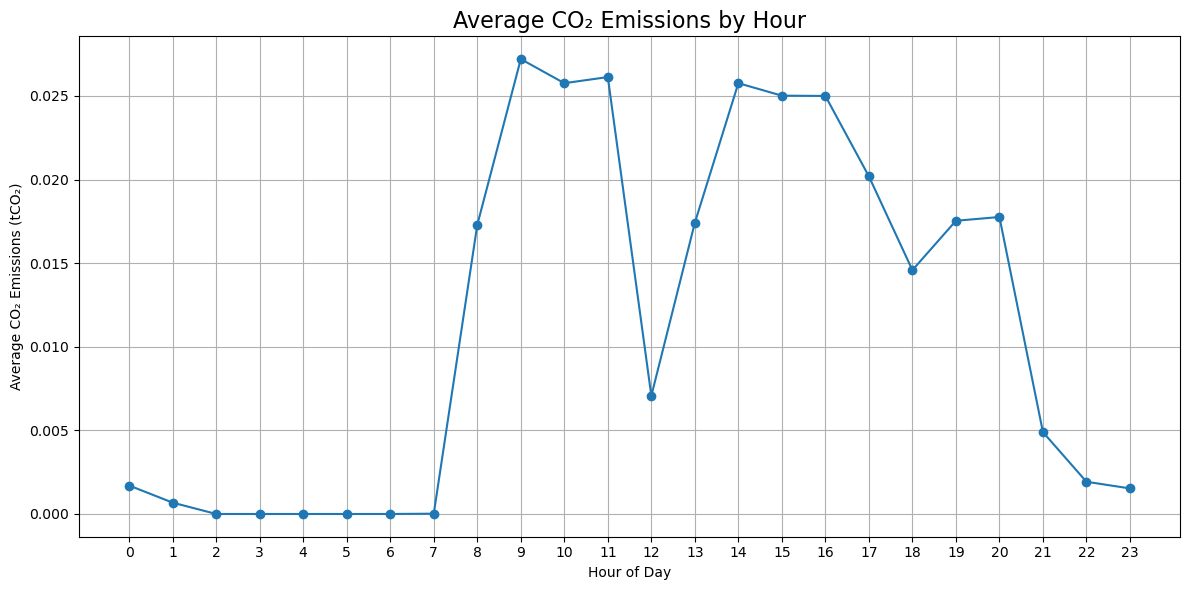

In [36]:
# 14. GRAPH 8 - CO2 BY HOUR

hourly_co2 = df.groupby("Hour")["CO2(tCO2)"].mean()

plt.figure(figsize=(12, 6))

plt.plot(hourly_co2.index,hourly_co2.values,marker="o")

plt.title("Average CO₂ Emissions by Hour",fontsize=16)

plt.xlabel("Hour of Day")
plt.ylabel("Average CO₂ Emissions (tCO₂)")

plt.xticks(range(0, 24))

plt.grid(True)

plt.tight_layout()
plt.show()


In [37]:
# 15. DEFINE FEATURES AND TARGET
# ============================================================

features = [
    "Usage_kWh",
    "Lagging_Current_Reactive.Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh",
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor",
    "NSM",
    "WeekStatus",
    "Day_Of_Week",
    "Load_Type"
]

target = "CO2(tCO2)"


X = df[features]
y = df[target]


print("\n" + "=" * 60)
print("FEATURES AND TARGET")
print("=" * 60)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(target)


FEATURES AND TARGET

Features:
['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_Of_Week', 'Load_Type']

Target:
CO2(tCO2)


In [38]:
# 16. DEFINE NUMERICAL AND CATEGORICAL FEATURES

numerical_features = [
    "Usage_kWh",
    "Lagging_Current_Reactive.Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh",
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor",
    "NSM"
]

categorical_features = [
    "WeekStatus",
    "Day_Of_Week",
    "Load_Type"
]

In [39]:
# 17. PREPROCESSING

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [40]:
# 18. TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 28032
Testing samples: 7009


In [41]:
# 19. DEFINE MODELS

models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(random_state=42,max_depth=10),

    "Random Forest": RandomForestRegressor(n_estimators=100,random_state=42,
            n_jobs=-1),

    "Gradient Boosting":
        GradientBoostingRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,
            random_state=42)
}


In [42]:
# 20. TRAIN MODELS

results = []

trained_models = {}

predictions = {}

print("\n" + "=" * 60)
print("MODEL TRAINING")
print("=" * 60)

for name, algorithm in models.items():

    print("\nTraining:", name)

    pipeline = Pipeline(steps=[("preprocessor",preprocessor),("regressor",algorithm)])

    pipeline.fit(X_train,y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test,y_pred)

    mse = mean_squared_error(y_test,y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test,y_pred)

    results.append({"Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    trained_models[name] = pipeline
    predictions[name] = y_pred

    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R²  :", r2)


MODEL TRAINING

Training: Linear Regression
MAE : 0.0013317048377901222
RMSE: 0.002158352859278083
R²  : 0.9825764619993059

Training: Decision Tree
MAE : 6.725760778725147e-05
RMSE: 0.0014340037612611408
R²  : 0.9923088366757338

Training: Random Forest
MAE : 8.065344557012894e-05
RMSE: 0.001194914200176729
R²  : 0.9946597093142955

Training: Gradient Boosting
MAE : 0.00012748014631744516
RMSE: 0.0011637347892436561
R²  : 0.9949347662962841


In [43]:
# 21. MODEL COMPARISON TABLE

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="R2 Score",ascending=False)

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(results_df)


MODEL COMPARISON
               Model       MAE      RMSE  R2 Score
3  Gradient Boosting  0.000127  0.001164  0.994935
2      Random Forest  0.000081  0.001195  0.994660
1      Decision Tree  0.000067  0.001434  0.992309
0  Linear Regression  0.001332  0.002158  0.982576


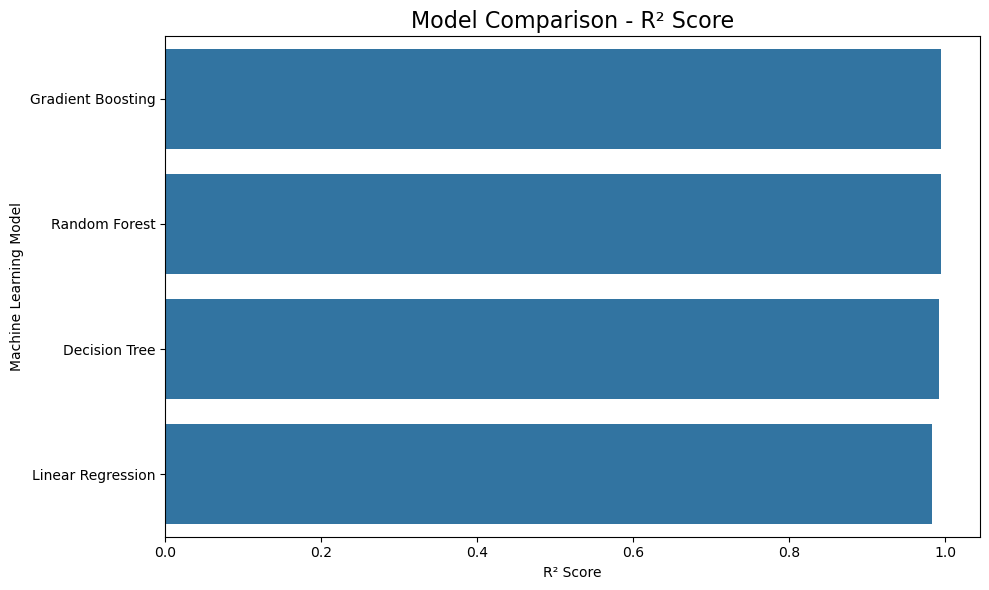

In [45]:
# 22. GRAPH 9 - MODEL COMPARISON

plt.figure(figsize=(10, 6))

sns.barplot(data=results_df,x="R2 Score",y="Model")

plt.title("Model Comparison - R² Score",fontsize=16)

plt.xlabel("R² Score")
plt.ylabel("Machine Learning Model")

plt.tight_layout()
plt.show()

In [46]:
# 23. FIND BEST MODEL

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

best_predictions = predictions[best_model_name]

print("\n" + "=" * 60)
print("BEST MODEL")
print("=" * 60)

print("Best Model:", best_model_name)


BEST MODEL
Best Model: Gradient Boosting


In [47]:
# 24. BEST MODEL METRICS

best_mae = mean_absolute_error(y_test,best_predictions)

best_rmse = np.sqrt(mean_squared_error(y_test,best_predictions))

best_r2 = r2_score(y_test,best_predictions)

print("\nBest Model Performance:")
print("MAE :", best_mae)
print("RMSE:", best_rmse)
print("R²  :", best_r2)


Best Model Performance:
MAE : 0.00012748014631744516
RMSE: 0.0011637347892436561
R²  : 0.9949347662962841


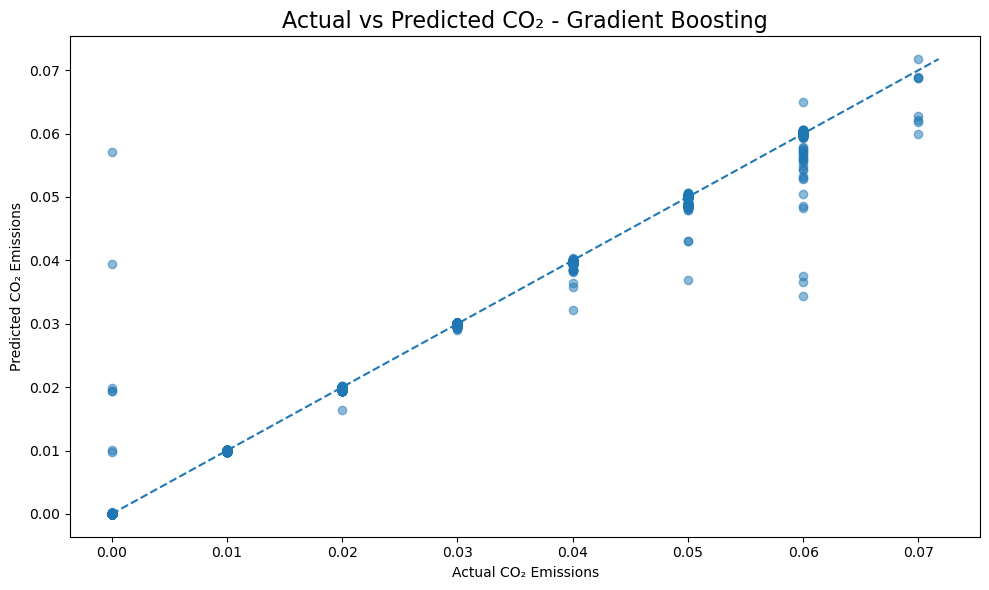

In [48]:
# 25. GRAPH 10 - ACTUAL VS PREDICTED

plt.figure(figsize=(10, 6))

plt.scatter(y_test,best_predictions,alpha=0.5)

# Perfect prediction line

minimum = min(y_test.min(),best_predictions.min())

maximum = max(y_test.max(),best_predictions.max())

plt.plot([minimum, maximum],[minimum, maximum],linestyle="--")

plt.title(f"Actual vs Predicted CO₂ - {best_model_name}",fontsize=16)

plt.xlabel("Actual CO₂ Emissions")
plt.ylabel("Predicted CO₂ Emissions")

plt.tight_layout()
plt.show()


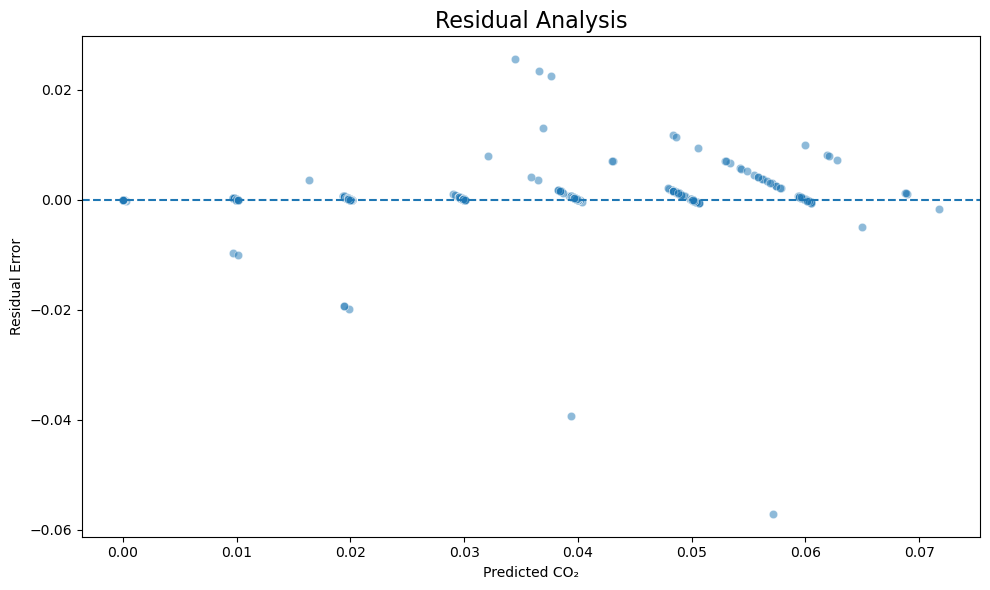

In [49]:
# 26. GRAPH 11 - RESIDUAL ANALYSIS

residuals = y_test - best_predictions

plt.figure(figsize=(10, 6))

sns.scatterplot(x=best_predictions,y=residuals,alpha=0.5)

plt.axhline(y=0,linestyle="--")

plt.title("Residual Analysis",fontsize=16)

plt.xlabel("Predicted CO₂")
plt.ylabel("Residual Error")

plt.tight_layout()
plt.show()


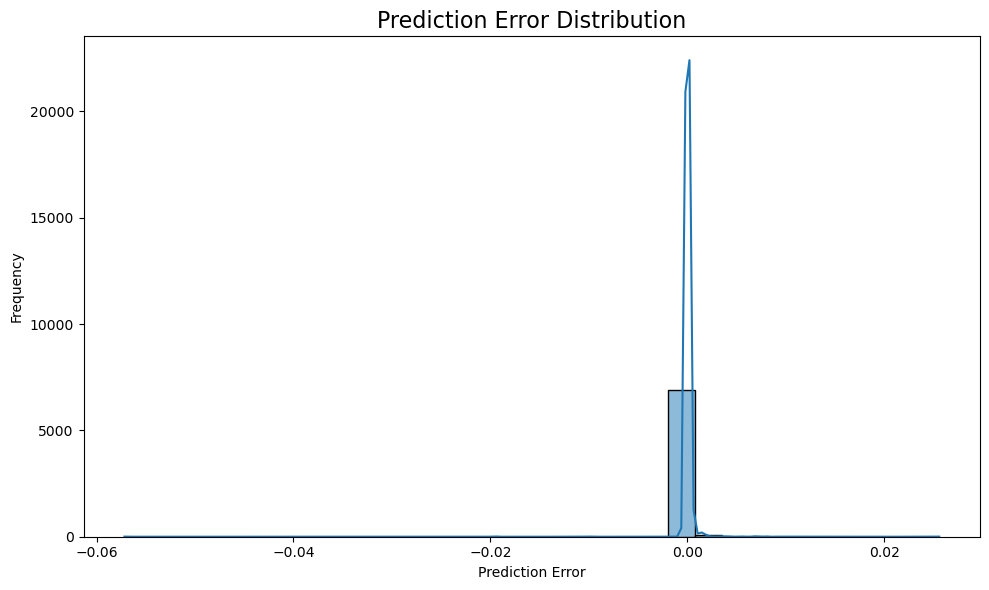

In [50]:
# 27. GRAPH 12 - ERROR DISTRIBUTION

plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title(
    "Prediction Error Distribution",
    fontsize=16
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [51]:
# 28. FEATURE IMPORTANCE

if best_model_name != "Linear Regression":

    model_step = best_model.named_steps["regressor"]

    preprocessor_step = best_model.named_steps["preprocessor"]

    feature_names = (preprocessor_step.get_feature_names_out())

    importances = model_step.feature_importances_

    importance_df = pd.DataFrame({"Feature": feature_names,"Importance": importances})

    importance_df = importance_df.sort_values(by="Importance",ascending=False)

    print("\n" + "=" * 60)
    print("FEATURE IMPORTANCE")
    print("=" * 60)

    print(importance_df)


FEATURE IMPORTANCE
                                            Feature  Importance
12                             remainder__Usage_kWh    0.997005
7                  categorical__Day_Of_Week_Tuesday    0.001583
13  remainder__Lagging_Current_Reactive.Power_kVarh    0.000706
15          remainder__Lagging_Current_Power_Factor    0.000251
17                                   remainder__NSM    0.000124
14  remainder__Leading_Current_Reactive_Power_kVarh    0.000097
6                 categorical__Day_Of_Week_Thursday    0.000095
16          remainder__Leading_Current_Power_Factor    0.000066
11               categorical__Load_Type_Medium_Load    0.000049
10              categorical__Load_Type_Maximum_Load    0.000024
0                   categorical__WeekStatus_Weekday    0.000000
1                   categorical__WeekStatus_Weekend    0.000000
8                categorical__Day_Of_Week_Wednesday    0.000000
5                   categorical__Day_Of_Week_Sunday    0.000000
4                 ca

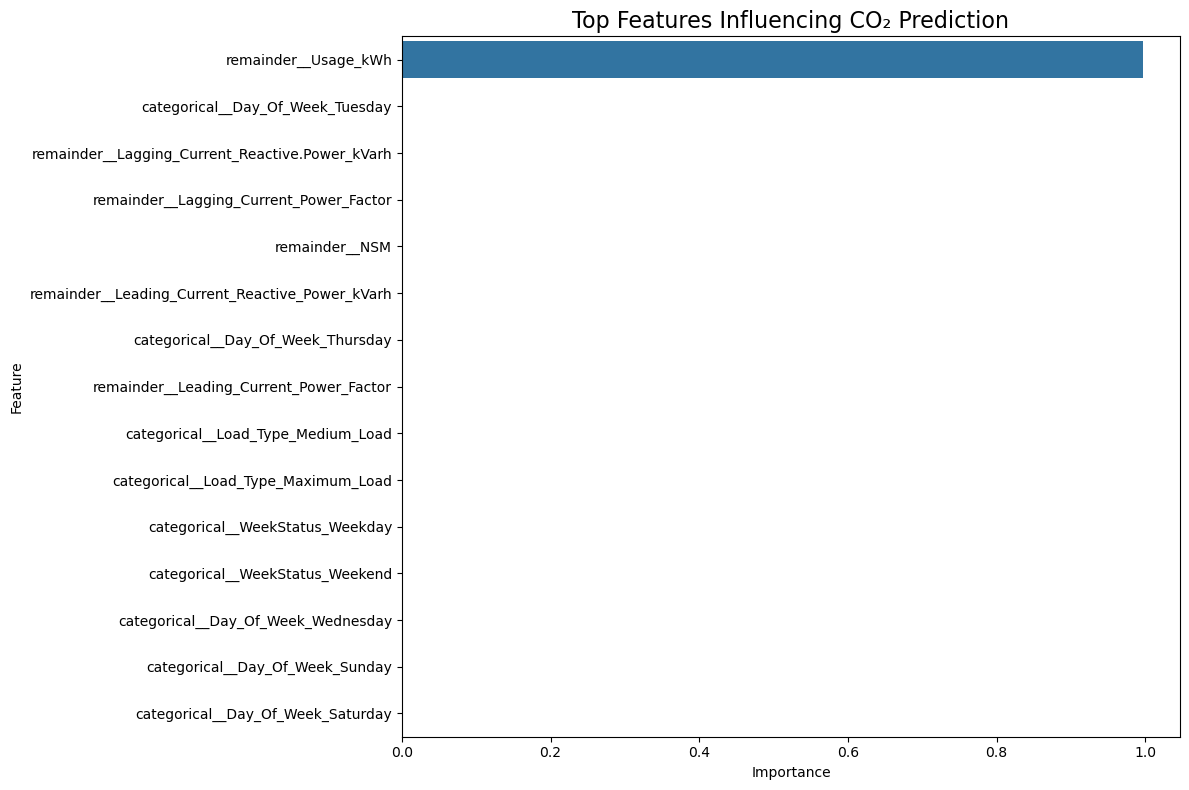

In [53]:
plt.figure(figsize=(12, 8))

sns.barplot(data=importance_df.head(15),x="Importance",y="Feature")

plt.title("Top Features Influencing CO₂ Prediction",fontsize=16)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


In [54]:
# 29. CREATE ACTUAL VS PREDICTED DATAFRAME

prediction_df = pd.DataFrame({"Actual_CO2": y_test.values,"Predicted_CO2": best_predictions})
prediction_df["Error"] = (prediction_df["Actual_CO2"]-prediction_df["Predicted_CO2"])

print("\nPrediction Results:")
print(prediction_df.head(20))


Prediction Results:
    Actual_CO2  Predicted_CO2     Error
0         0.00       0.000017 -0.000017
1         0.03       0.030042 -0.000042
2         0.06       0.059864  0.000136
3         0.00       0.000017 -0.000017
4         0.03       0.029967  0.000033
5         0.00       0.000017 -0.000017
6         0.02       0.019798  0.000202
7         0.00       0.000017 -0.000017
8         0.00       0.000012 -0.000012
9         0.00       0.000017 -0.000017
10        0.00       0.000017 -0.000017
11        0.00       0.000017 -0.000017
12        0.00       0.000012 -0.000012
13        0.03       0.030042 -0.000042
14        0.00       0.000017 -0.000017
15        0.04       0.039898  0.000102
16        0.00       0.000017 -0.000017
17        0.05       0.050076 -0.000076
18        0.03       0.030042 -0.000042
19        0.02       0.019841  0.000159


In [57]:
# 30. REAL-TIME PREDICTION FUNCTION

def predict_carbon_emission(
    usage_kwh,
    lagging_reactive,
    leading_reactive,
    lagging_power_factor,
    leading_power_factor,
    nsm,
    week_status,
    day_of_week,
    load_type
):

    input_data = pd.DataFrame({"Usage_kWh": [usage_kwh],
                           "Lagging_Current_Reactive.Power_kVarh":[lagging_reactive],
                           "Leading_Current_Reactive_Power_kVarh":[leading_reactive],
                           "Lagging_Current_Power_Factor":[lagging_power_factor],
                           "Leading_Current_Power_Factor":[leading_power_factor],
                           "NSM": [nsm],"WeekStatus": [week_status],
                           "Day_Of_Week": [day_of_week],"Load_Type": [load_type]})
    prediction = best_model.predict(input_data)
    return prediction[0]

In [58]:
# 31. TEST REAL-TIME PREDICTION

example_prediction = predict_carbon_emission(

    usage_kwh=300,

    lagging_reactive=100,

    leading_reactive=20,

    lagging_power_factor=80,

    leading_power_factor=95,

    nsm=36000,

    week_status="Weekday",

    day_of_week="Monday",

    load_type="Medium_Load"
)

print("\n" + "=" * 60)
print("REAL-TIME CARBON PREDICTION")
print("=" * 60)

print("Predicted CO₂:",round(example_prediction, 4),"tCO₂")



REAL-TIME CARBON PREDICTION
Predicted CO₂: 0.0514 tCO₂


In [61]:
# 32. SAVE BEST MODEL

joblib.dump(best_model,"carbon_emission_model.pkl")

print("\nModel saved as: carbon_emission_model.pkl")


Model saved as: carbon_emission_model.pkl


In [62]:
# 33. SAVE MODEL RESULTS

results_df.to_csv("model_comparison.csv",index=False)

prediction_df.to_csv("prediction_results.csv",index=False)

print("Model comparison saved.")
print("Prediction results saved.")

Model comparison saved.
Prediction results saved.


In [63]:
# 34. FINAL PROJECT SUMMARY

print("\n")
print("=" * 60)
print("PROJECT COMPLETED")
print("=" * 60)

print("Dataset rows       :", df.shape[0])
print("Dataset columns    :", df.shape[1])
print("Best model         :", best_model_name)
print("MAE                :", round(best_mae, 4))
print("RMSE               :", round(best_rmse, 4))
print("R² Score           :", round(best_r2, 4))
print("Saved model        : carbon_emission_model.pkl")
print("=" * 60)



PROJECT COMPLETED
Dataset rows       : 35041
Dataset columns    : 15
Best model         : Gradient Boosting
MAE                : 0.0001
RMSE               : 0.0012
R² Score           : 0.9949
Saved model        : carbon_emission_model.pkl
